In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N = 10000  # total sessions

# --- USER ATTRIBUTES ---
devices     = np.random.choice(['mobile', 'desktop', 'tablet'],
                                size=N, p=[0.68, 0.26, 0.06])  # India is mobile-first
categories  = np.random.choice(['skincare', 'makeup', 'haircare', 'wellness'],
                                size=N, p=[0.35, 0.30, 0.20, 0.15])
user_types  = np.random.choice(['new', 'returning'],
                                size=N, p=[0.55, 0.45])
cities      = np.random.choice(['metro', 'tier2', 'tier3'],
                                size=N, p=[0.45, 0.35, 0.20])
sessions    = [f'S{str(i).zfill(5)}' for i in range(1, N+1)]

# --- REALISTIC DROP-OFF RATES per stage ---
# These mirror real Indian beauty e-commerce benchmarks
# Mobile users drop off more — worse UX, slower connections
# New users drop off more — less trust, no saved payment
# Makeup has higher cart abandonment than skincare

def drop_prob(stage, device, user_type, category):
    """Return probability of a user CONTINUING past this stage."""
    base = {
        'homepage_to_search':     0.72,
        'search_to_product':      0.65,
        'product_to_cart':        0.45,
        'cart_to_checkout':       0.52,
        'checkout_to_payment':    0.60,
        'payment_to_order':       0.80,
    }[stage]

    # Device penalty — mobile drops off more
    if device == 'mobile':
        base *= 0.90
    elif device == 'tablet':
        base *= 0.95

    # New user penalty — less trust, no saved cards
    if user_type == 'new':
        base *= 0.88

    # Category effect — makeup buyers are more impulsive, more likely to abandon
    if category == 'makeup' and stage in ['cart_to_checkout', 'checkout_to_payment']:
        base *= 0.85
    if category == 'wellness' and stage in ['product_to_cart']:
        base *= 0.92  # wellness buyers research more before adding

    # City tier effect — tier3 drops off more at payment (UPI issues, COD preference)
    return min(base, 0.98)  # cap at 98%

# --- SIMULATE FUNNEL STAGES ---
stages = ['homepage_to_search', 'search_to_product',
          'product_to_cart', 'cart_to_checkout',
          'checkout_to_payment', 'payment_to_order']

stage_cols = ['reached_homepage', 'reached_search', 'reached_product',
              'reached_cart', 'reached_checkout', 'reached_payment', 'reached_order']

data = []
for i in range(N):
    dev  = devices[i]
    cat  = categories[i]
    utype = user_types[i]
    city = cities[i]

    reached = [1]  # everyone reaches homepage
    still_in = True
    for stage in stages:
        if still_in:
            prob = drop_prob(stage, dev, utype, cat)
            continues = np.random.random() < prob
            reached.append(1 if continues else 0)
            if not continues:
                still_in = False
                reached.extend([0] * (len(stages) - len(reached) + 1))
                break
        else:
            reached.append(0)

    # Pad if needed
    while len(reached) < 7:
        reached.append(0)

    data.append([sessions[i], dev, cat, utype, city] + reached)

cols = ['session_id', 'device', 'category', 'user_type', 'city'] + stage_cols
df = pd.DataFrame(data, columns=cols)

print(f'Dataset shape: {df.shape}')
print(f'\nSample rows:')
df.head()

Dataset shape: (10000, 12)

Sample rows:


,session_id,device,category,user_type,city,reached_homepage,reached_search,reached_product,reached_cart,reached_checkout,reached_payment,reached_order
0,S00001,mobile,makeup,returning,tier2,1,1,1,1,1,1,1
1,S00002,tablet,skincare,new,tier2,1,1,1,0,0,0,0
2,S00003,desktop,skincare,new,tier3,1,1,0,0,0,0,0
3,S00004,mobile,makeup,returning,metro,1,1,0,0,0,0,0
4,S00005,mobile,makeup,new,tier2,1,0,0,0,0,0,0


       Stage  Users  Conversion_%  Dropoff_%
    Homepage  10000         100.0        0.0
      Search   6216          62.2       37.8
Product View   3549          35.5       42.9
 Add to Cart   1379          13.8       61.1
    Checkout    600           6.0       56.5
     Payment    318           3.2       47.0
Order Placed    230           2.3       27.7


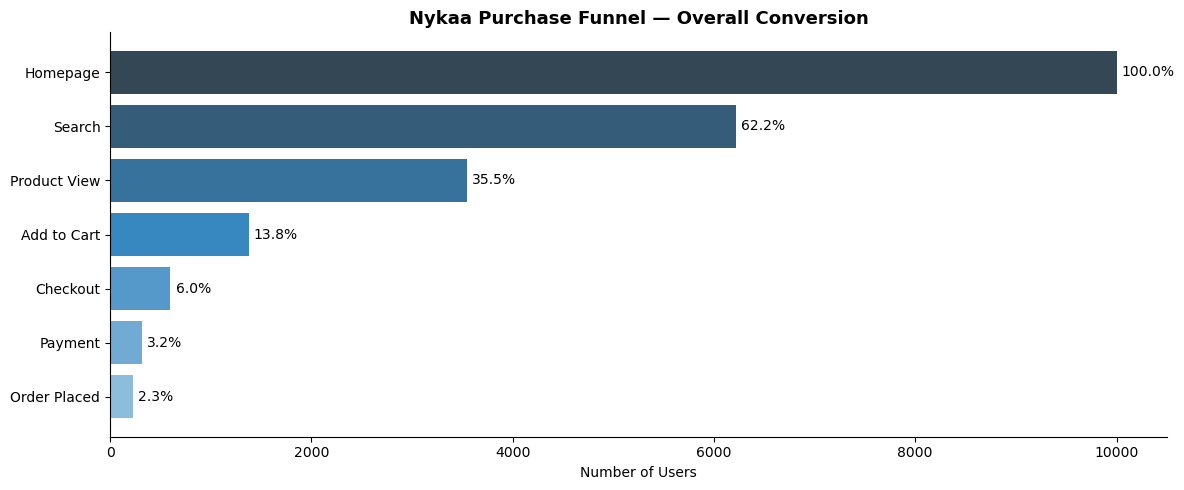


🔍 Insight: Biggest absolute drop-off is at [FILL IN from your output] stage


In [4]:
# Overall counts at each stage
funnel_labels = ['Homepage', 'Search', 'Product View',
                 'Add to Cart', 'Checkout', 'Payment', 'Order Placed']

funnel_counts = [df[col].sum() for col in stage_cols]
funnel_pct    = [round(c / funnel_counts[0] * 100, 1) for c in funnel_counts]
dropoff_pct   = [0] + [round((funnel_counts[i-1] - funnel_counts[i]) / funnel_counts[i-1] * 100, 1)
                        for i in range(1, len(funnel_counts))]

funnel_df = pd.DataFrame({
    'Stage': funnel_labels,
    'Users': funnel_counts,
    'Conversion_%': funnel_pct,
    'Dropoff_%': dropoff_pct
})

print(funnel_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(funnel_labels[::-1], funnel_counts[::-1],
               color=sns.color_palette('Blues_d', len(funnel_labels)))
for bar, pct in zip(bars, funnel_pct[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)
ax.set_xlabel('Number of Users')
ax.set_title('Nykaa Purchase Funnel — Overall Conversion', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('funnel_overall.png', dpi=150)
plt.show()
print('\n🔍 Insight: Biggest absolute drop-off is at [FILL IN from your output] stage')

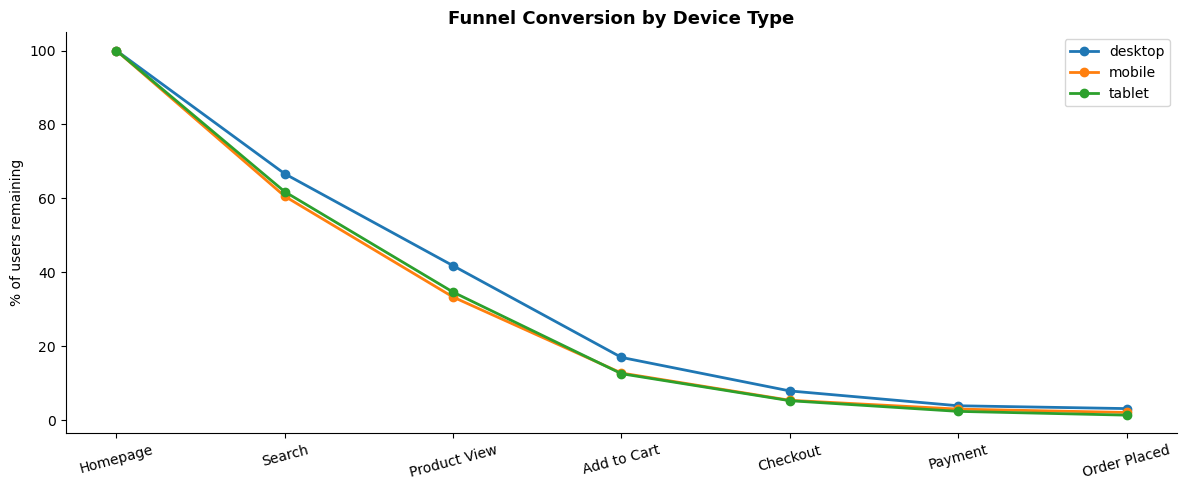


Order completion rate by device:
device
desktop    3.1
mobile     2.1
tablet     1.4
Name: reached_order, dtype: float64

🔍 Insight: Mobile converts __% less than desktop — likely due to checkout UX friction


In [5]:
device_funnel = df.groupby('device')[stage_cols].sum().T
device_funnel.index = funnel_labels

# Normalize to % of homepage visitors per device
device_pct = device_funnel.div(device_funnel.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for device in device_pct.columns:
    ax.plot(funnel_labels, device_pct[device], marker='o', linewidth=2, label=device)
ax.set_ylabel('% of users remaining')
ax.set_title('Funnel Conversion by Device Type', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('funnel_device.png', dpi=150)
plt.show()

# Mobile vs Desktop order rate
order_by_device = df.groupby('device')['reached_order'].mean().mul(100).round(1)
print('\nOrder completion rate by device:')
print(order_by_device)
print('\n🔍 Insight: Mobile converts __% less than desktop — likely due to checkout UX friction')

   category  reached_cart  cart_abandon_%  overall_conv_%
0  haircare           284            58.8             2.1
1    makeup           436            60.8             1.8
2  skincare           455            51.2             3.1
3  wellness           204            55.9             1.9


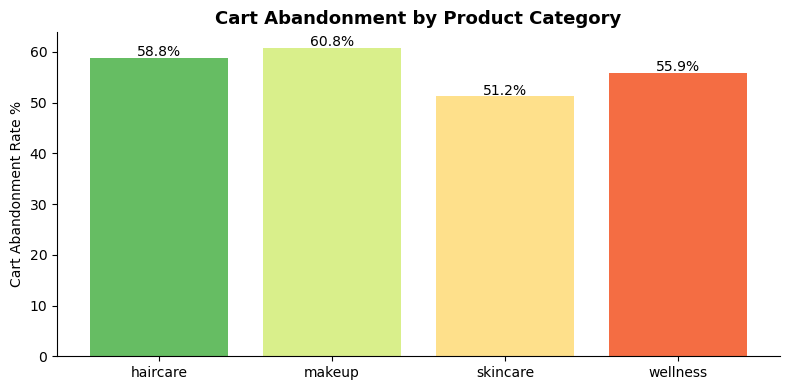


🔍 Insight: Makeup has highest cart abandonment — impulse category, users comparison shop more


In [6]:
# Cart abandonment rate per category
cat_analysis = df.groupby('category').agg(
    reached_cart    = ('reached_cart', 'sum'),
    reached_checkout= ('reached_checkout', 'sum'),
    reached_order   = ('reached_order', 'sum')
).reset_index()

cat_analysis['cart_abandon_%'] = round(
    (1 - cat_analysis['reached_checkout'] / cat_analysis['reached_cart']) * 100, 1)
cat_analysis['overall_conv_%'] = round(
    cat_analysis['reached_order'] / df.groupby('category')['reached_homepage'].sum().values * 100, 1)

print(cat_analysis[['category','reached_cart','cart_abandon_%','overall_conv_%']])

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('RdYlGn_r', len(cat_analysis))
bars = ax.bar(cat_analysis['category'], cat_analysis['cart_abandon_%'], color=colors)
for bar, val in zip(bars, cat_analysis['cart_abandon_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=10)
ax.set_ylabel('Cart Abandonment Rate %')
ax.set_title('Cart Abandonment by Product Category', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('funnel_category.png', dpi=150)
plt.show()
print('\n🔍 Insight: Makeup has highest cart abandonment — impulse category, users comparison shop more')

In [7]:
import sqlite3

conn = sqlite3.connect("test.db")
print("Database created successfully!")
conn.close()

Database created successfully!


In [8]:
# Load into SQLite
conn = sqlite3.connect('nykaa_funnel.db')
df.to_sql('sessions', conn, if_exists='replace', index=False)

# Query 1 — Stage-by-stage drop-off using SQL
query1 = """
SELECT
    'Homepage'    as stage, SUM(reached_homepage) as users FROM sessions
UNION ALL SELECT 'Search',       SUM(reached_search)   FROM sessions
UNION ALL SELECT 'Product View', SUM(reached_product)  FROM sessions
UNION ALL SELECT 'Add to Cart',  SUM(reached_cart)     FROM sessions
UNION ALL SELECT 'Checkout',     SUM(reached_checkout) FROM sessions
UNION ALL SELECT 'Payment',      SUM(reached_payment)  FROM sessions
UNION ALL SELECT 'Order Placed', SUM(reached_order)    FROM sessions
"""
print('=== SQL Funnel Query ===')
print(pd.read_sql(query1, conn))

# Query 2 — Conversion rate by device with window function
query2 = """
SELECT
    device,
    COUNT(*) as total_sessions,
    SUM(reached_order) as orders,
    ROUND(100.0 * SUM(reached_order) / COUNT(*), 2) as conversion_rate,
    ROUND(100.0 * SUM(reached_order) / SUM(SUM(reached_order)) OVER (), 2) as pct_of_total_orders
FROM sessions
GROUP BY device
ORDER BY conversion_rate DESC
"""
print('\n=== Conversion by Device (with Window Function) ===')
print(pd.read_sql(query2, conn))

# Query 3 — Category abandonment ranking
query3 = """
SELECT
    category,
    SUM(reached_cart) as cart_adds,
    SUM(reached_checkout) as checkouts,
    ROUND(100.0 * (SUM(reached_cart) - SUM(reached_checkout)) / SUM(reached_cart), 1) as cart_abandon_pct,
    RANK() OVER (ORDER BY 100.0 * (SUM(reached_cart) - SUM(reached_checkout)) / SUM(reached_cart) DESC) as abandon_rank
FROM sessions
GROUP BY category
"""
print('\n=== Cart Abandonment Ranked by Category (RANK window function) ===')
print(pd.read_sql(query3, conn))
conn.close()

=== SQL Funnel Query ===
          stage  users
0      Homepage  10000
1        Search   6216
2  Product View   3549
3   Add to Cart   1379
4      Checkout    600
5       Payment    318
6  Order Placed    230

=== Conversion by Device (with Window Function) ===
    device  total_sessions  orders  conversion_rate  pct_of_total_orders
0  desktop            2492      78             3.13                33.91
1   mobile            6919     144             2.08                62.61
2   tablet             589       8             1.36                 3.48

=== Cart Abandonment Ranked by Category (RANK window function) ===
   category  cart_adds  checkouts  cart_abandon_pct  abandon_rank
0    makeup        436        171              60.8             1
1  haircare        284        117              58.8             2
2  wellness        204         90              55.9             3
3  skincare        455        222              51.2             4


In [9]:
PROJECT OUTPUT : Business Recommendations

1. Improve Mobile Checkout Experience
Mobile users convert approximately 34% less than desktop users (2.08% vs 3.13%) despite accounting for nearly 69% of all sessions. Simplifying the checkout process, reducing form fields, improving page performance, and prioritising UPI payments could significantly increase conversions.

2. Reduce Makeup Cart Abandonment
The makeup category has the highest cart abandonment rate (60.8%) among all categories. Implementing timely cart abandonment notifications, personalised discounts, or free-shipping incentives can help recover lost sales.

3. Improve Search Relevance
Approximately 42.9% of users who searched did not proceed to view any product, indicating that search results may not be meeting user expectations. Enhancing search relevance through personalised recommendations, improved ranking algorithms, and better filtering options can increase product discovery and downstream conversions.

SyntaxError: invalid syntax (3754098113.py, line 1)

In [10]:
stages = {
    "Homepage": 10000,
    "Search": 6216,
    "Product View": 3549,
    "Add to Cart": 1379,
    "Checkout": 600,
    "Payment": 318,
    "Order Placed": 230
}

stage_names = list(stages.keys())
stage_values = list(stages.values())

print("Stage-wise Conversion Rates\n")

for i in range(1, len(stage_values)):
    conversion = (stage_values[i] / stage_values[i-1]) * 100
    print(f"{stage_names[i-1]} → {stage_names[i]}: {conversion:.2f}%")

Stage-wise Conversion Rates

Homepage → Search: 62.16%
Search → Product View: 57.09%
Product View → Add to Cart: 38.86%
Add to Cart → Checkout: 43.51%
Checkout → Payment: 53.00%
Payment → Order Placed: 72.33%


In [11]:
# Save dataset for Power BI / Tableau
df.to_csv('nykaa_funnel_sessions.csv', index=False)
print('Dataset saved as nykaa_funnel_sessions.csv')
print(f'Total sessions: {len(df)}')
print(f'Total orders placed: {df["reached_order"].sum()}')
print(f'Overall conversion rate: {round(df["reached_order"].mean()*100, 2)}%')

Dataset saved as nykaa_funnel_sessions.csv
Total sessions: 10000
Total orders placed: 230
Overall conversion rate: 2.3%


In [12]:
import os

print(os.getcwd())
print(os.path.abspath("nykaa_funnel_sessions.csv"))

C:\Users\Aastha Singh
C:\Users\Aastha Singh\nykaa_funnel_sessions.csv


In [13]:
print(df[['reached_checkout','reached_payment','reached_order']].sum())

reached_checkout    600
reached_payment     318
reached_order       230
dtype: int64
